<a href="https://colab.research.google.com/github/ganeshkumar1887/Deep-learning/blob/main/Deep%20learning%20progress/Day%204/SVM_adaboost_with_influenza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
df = pd.read_excel("/content/drive/MyDrive/Advanced Machine learning/Datasets/Influenza_surveillance_Data.xlsx")

In [5]:
df.head()

,Pathogen Test Result,Host Sex,Host Age,diarrhea,cough,running nose,myalgia,short breath,nausea,headache,...,Obesity,hepatobiliary_disease,respiratory_disease,urogenital_disease,Other_Chronic_Conditions,Allergies,chronic_lung_disease,Immunosuppression,autoimmune_disorder,endocrine_metabolic_disorder
0,0,1,26,0,1,1,1,1,1,1,...,1,0,0,0,1,0,1,0,0,0
1,0,0,12,0,1,1,0,1,1,1,...,0,0,0,0,1,0,0,0,0,0
2,0,1,0,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,0,0,0
3,1,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,20,0,1,1,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0


In [6]:
X = df.drop('Pathogen Test Result', axis=1)
y = df['Pathogen Test Result']

In [7]:
X.shape

(7428, 34)

In [8]:
y.shape

(7428,)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7428 entries, 0 to 7427
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Pathogen Test Result                      7428 non-null   int64
 1   Host Sex                                  7428 non-null   int64
 2   Host Age                                  7428 non-null   int64
 3   diarrhea                                  7428 non-null   int64
 4   cough                                     7428 non-null   int64
 5   running nose                              7428 non-null   int64
 6   myalgia                                   7428 non-null   int64
 7   short breath                              7428 non-null   int64
 8   nausea                                    7428 non-null   int64
 9   headache                                  7428 non-null   int64
 10  malaise                                   7428 non-null   in

In [10]:
df.isnull().sum()

,0
Pathogen Test Result,0
Host Sex,0
Host Age,0
diarrhea,0
cough,0
running nose,0
myalgia,0
short breath,0
nausea,0
headache,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5571
Testing samples: 1857


In [12]:
base_model = SVC(kernel='linear')

In [13]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=SVC(kernel='linear'), learning_rate=1,
                   random_state=42)

In [14]:
y_pred = ada_model.predict(X_test)


In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6192784060312332


In [16]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      1004
           1       0.60      0.51      0.55       853

    accuracy                           0.62      1857
   macro avg       0.62      0.61      0.61      1857
weighted avg       0.62      0.62      0.62      1857



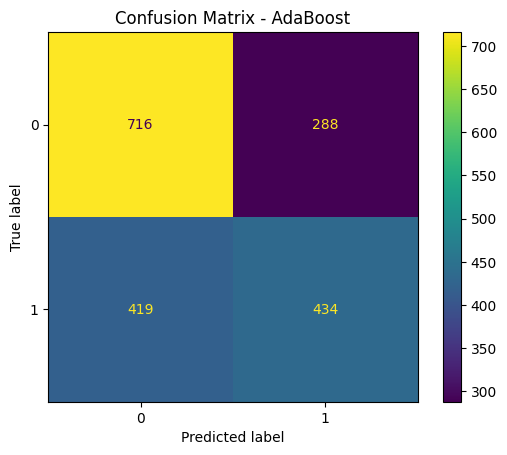

In [17]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - AdaBoost")
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier

ada_model_dt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5), # Using DecisionTreeClassifier as base estimator
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

ada_model_dt.fit(X_train, y_train)

importances = ada_model_dt.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
1,Host Age,0.269869
8,headache,0.081230
13,TB,0.064838
11,fever,0.060971
3,cough,0.058478
7,nausea,0.035574
30,chronic_lung_disease,0.035018
0,Host Sex,0.031785
9,malaise,0.030606
4,running nose,0.029530


In [ ]:
train_acc = []
test_acc = []

for i in range(1, 101):
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=i,
        random_state=42
    )
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,101), train_acc, label='Training Accuracy')
plt.plot(range(1,101), test_acc, label='Testing Accuracy')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance vs Number of Estimators")
plt.legend()
plt.show()